# Detecting Potential Medicare DMEPOS Fraud Using HCPCS Billing Patterns

## Research Objective

This analysis investigates potential fraud risk in Medicare Durable Medical Equipment, Prosthetics, Orthotics, and Supplies (DMEPOS) supplier billing data.

The goal is to:

1. Identify **high-risk HCPCS codes** using statistical indicators.
2. Detect **Missouri suppliers with unusually high billing activity**.
3. Identify **temporal billing anomalies**, specifically suppliers with a spike pattern:
   
Low billing → Sudden spike → Rapid decline

This pattern is commonly associated with fraudulent billing schemes where suppliers aggressively bill during a short window before stopping activity.

## Data Loading and Environment Setup

The dataset contains supplier-level Medicare billing data for DMEPOS services.

Each record represents supplier activity for a specific HCPCS code and year.

Key variables include:

- `suplr_npi` — Supplier identifier
- `hcpcs_cd` — Procedure code
- `tot_suplr_srvcs` — Total services billed
- `avg_suplr_mdcr_pymt_amt` — Average Medicare payment
- `year` — Reporting year

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_serv_clean.csv")

df.head()

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,...,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3808,"Wrist hand finger orthosis, rigid without join...",N,69.0,79,82,435.609756,325.202683,257.561707,262.395732
1,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3906,"Wrist hand orthosis, without joints, may inclu...",N,30.0,30,35,448.285714,439.852857,351.134286,315.416286
2,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3908,"Wrist hand orthosis, wrist extension control c...",N,84.0,99,107,108.457944,66.980000,51.914953,46.384393
3,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3913,"Hand finger orthosis, without joints, may incl...",N,16.0,16,16,348.000000,247.410000,197.133125,191.759375
4,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3923,"Hand finger orthosis, without joints, may incl...",N,54.0,59,66,113.030303,88.250000,66.411515,65.491667


## Dataset Structure

Before conducting the analysis, we inspect the dataset to understand available variables.

In [11]:
print(df.shape)
print(df.columns)
df.describe()

(1454474, 33)
Index(['year', 'suplr_npi', 'suplr_prvdr_last_name_org',
       'suplr_prvdr_first_name', 'suplr_prvdr_mi', 'suplr_prvdr_crdntls',
       'suplr_prvdr_ent_cd', 'suplr_prvdr_st1', 'suplr_prvdr_st2',
       'suplr_prvdr_city', 'suplr_prvdr_state_abrvtn',
       'suplr_prvdr_state_fips', 'suplr_prvdr_zip5', 'suplr_prvdr_ruca_cat',
       'suplr_prvdr_ruca', 'suplr_prvdr_ruca_desc', 'suplr_prvdr_cntry',
       'suplr_prvdr_spclty_cd', 'suplr_prvdr_spclty_desc',
       'suplr_prvdr_spclty_srce', 'rbcs_lvl', 'rbcs_id', 'rbcs_desc',
       'hcpcs_cd', 'hcpcs_desc', 'suplr_rentl_ind', 'tot_suplr_benes',
       'tot_suplr_clms', 'tot_suplr_srvcs', 'avg_suplr_sbmtd_chrg',
       'avg_suplr_mdcr_alowd_amt', 'avg_suplr_mdcr_pymt_amt',
       'avg_suplr_mdcr_stdzd_amt'],
      dtype='object')


,year,suplr_npi,suplr_prvdr_state_fips,suplr_prvdr_zip5,suplr_prvdr_ruca,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt
count,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06,1.454474e+06
mean,2.021970e+03,1.502034e+09,2.856412e+01,4.914111e+04,2.140909e+00,6.015313e+01,1.647799e+02,4.576480e+03,2.056878e+02,1.010626e+02,7.798224e+01,7.767823e+01
std,8.168502e-01,2.883286e+08,1.550741e+01,2.749516e+04,2.752428e+00,4.803591e+02,1.892079e+03,4.952015e+05,9.028967e+02,4.198971e+02,3.283998e+02,3.193373e+02
min,2.021000e+03,1.003000e+09,1.000000e+00,6.050000e+02,1.000000e+00,5.000000e+00,1.100000e+01,1.100000e+01,3.348654e-04,3.348654e-04,0.000000e+00,0.000000e+00
25%,2.021000e+03,1.255406e+09,1.700000e+01,2.836500e+04,1.000000e+00,5.000000e+00,1.600000e+01,2.700000e+01,1.321108e+01,2.799809e+00,2.087560e+00,2.183343e+00
50%,2.022000e+03,1.508413e+09,2.800000e+01,4.656300e+04,1.000000e+00,1.400000e+01,2.900000e+01,9.600000e+01,3.659725e+01,1.600000e+01,1.261647e+01,1.254000e+01
75%,2.023000e+03,1.750331e+09,4.200000e+01,7.274500e+04,2.000000e+00,3.500000e+01,7.900000e+01,6.960000e+02,1.150000e+02,5.661000e+01,4.196140e+01,4.371000e+01
max,2.023000e+03,1.992999e+09,7.800000e+01,9.990100e+04,9.900000e+01,1.127970e+05,8.590970e+05,2.967321e+08,7.761210e+04,2.773326e+04,2.174288e+04,2.149642e+04


## Identifying High-Risk HCPCS Codes

Certain HCPCS codes appear more frequently in Medicare fraud investigations.  
To identify these codes in a data-driven way, we construct a **risk score** based on:

1. **Total services billed**
2. **Average Medicare payment amount**
3. **Supplier concentration**

Supplier concentration measures the average number of services billed per supplier.

A high concentration may indicate that a small group of suppliers dominate billing for a code, which can signal fraud risk.

The risk score is calculated using standardized (z-score) values to normalize each metric.

In [12]:
hcpcs_stats = (
    df
    .groupby("hcpcs_cd")
    .agg({
        "tot_suplr_srvcs":"sum",
        "avg_suplr_mdcr_pymt_amt":"mean",
        "suplr_npi":"nunique"
    })
    .reset_index()
)

hcpcs_stats["supplier_concentration"] = (
    hcpcs_stats["tot_suplr_srvcs"] / hcpcs_stats["suplr_npi"]
)

hcpcs_stats["risk_score"] = (
    zscore(hcpcs_stats["tot_suplr_srvcs"]) +
    zscore(hcpcs_stats["avg_suplr_mdcr_pymt_amt"]) +
    zscore(hcpcs_stats["supplier_concentration"])
)

high_risk_codes = (
    hcpcs_stats
    .sort_values("risk_score", ascending=False)
    .head(10)
)

high_risk_codes

,hcpcs_cd,tot_suplr_srvcs,avg_suplr_mdcr_pymt_amt,suplr_npi,supplier_concentration,risk_score
747,J7677,2267874837,0.149145,1543,1.469783e+06,62.049102
37,A4353,441402975,6.541383,474,9.312299e+05,24.378263
1164,L5856,202,20037.552933,13,1.553846e+01,19.444628
1175,L5973,36,14713.314697,2,1.800000e+01,14.144892
481,E0766,11771,11264.402448,1,1.177100e+04,10.943328
315,B4152,341472223,0.313453,1608,2.123583e+05,8.741169
36,A4352,184850703,5.593406,798,2.316425e+05,6.804121
530,E1008,14,7085.390714,1,1.400000e+01,6.551927
529,E1007,42938,6751.682249,458,9.375109e+01,6.221957
740,J7613,394695512,0.029330,21288,1.854075e+04,5.715022


## Extract High Risk HCPCS Codes

In [13]:
high_risk_list = high_risk_codes["hcpcs_cd"].tolist()

high_risk_list

['J7677',
 'A4353',
 'L5856',
 'L5973',
 'E0766',
 'B4152',
 'A4352',
 'E1008',
 'E1007',
 'J7613']

## Missouri Supplier Filtering

To focus the analysis on a specific geographic region, we limit the dataset to suppliers located in Missouri.

In [14]:
df_mo = df[df["suplr_prvdr_state_abrvtn"] == "MO"]

df_mo = df_mo[df_mo["hcpcs_cd"].isin(high_risk_list)]

df_mo.head()

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,...,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt
2548,2021,1003821240,Walgreen Co,NaN,NaN,NaN,O,7501 Olive Blvd,NaN,University City,...,J7613,"Albuterol, inhalation solution, fda-approved f...",N,5.0,17,4932,0.340558,0.043867,0.030075,0.029467
2557,2021,1003821257,Walgreen Co,NaN,NaN,NaN,O,1 S Kingshighway,NaN,Cape Girardeau,...,J7613,"Albuterol, inhalation solution, fda-approved f...",N,12.0,39,7020,0.574590,0.044808,0.026607,0.026067
4195,2021,1003887753,United Seating And Mobility Llc,NaN,NaN,NaN,O,2414e W Battlefield St,NaN,Springfield,...,E1007,"Wheelchair accessory, power seating system, co...",N,22.0,22,22,24584.045455,8724.672727,6979.738182,6403.710000
8358,2021,1013349299,Missouri Cvs Pharmacy Llc,NaN,NaN,NaN,O,100 E Broadway Blvd,NaN,Sedalia,...,J7613,"Albuterol, inhalation solution, fda-approved f...",N,11.0,16,2782,0.568634,0.045507,0.032915,0.032257
8682,2021,1013434851,"Mercy Pharmacy Services, Llc",NaN,NaN,NaN,O,940 W Mount Vernon St Ste 130,NaN,Nixa,...,J7613,"Albuterol, inhalation solution, fda-approved f...",N,5.0,15,590,1.670339,0.044305,0.025627,0.025153


## Top Suppliers Billing High Risk HCPCS Codes

We identify suppliers with the highest total service volume for high-risk HCPCS codes.

In [15]:
supplier_billing = (
    df_mo
    .groupby(["suplr_npi","hcpcs_cd"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

top_suppliers = (
    supplier_billing
    .sort_values("tot_suplr_srvcs", ascending=False)
    .head(10)
)

top_suppliers

,suplr_npi,hcpcs_cd,tot_suplr_srvcs
86,1134698418,J7677,135624621
66,1114943610,J7677,54166875
85,1134698418,J7613,30937428
65,1114943610,J7613,6228718
29,1043395833,B4152,2026623
228,1376916379,B4152,1662928
364,1568537009,B4152,1279524
213,1366475022,B4152,1239515
336,1528069309,B4152,840362
291,1467482281,J7677,813750


## Temporal Billing Patterns

Next, we examine how billing behavior changes over time for the top suppliers.

Fraud investigations often look for **abnormal spikes in billing activity**.

In [17]:
top_npis = top_suppliers["suplr_npi"].unique()

trend_df = df_mo[df_mo["suplr_npi"].isin(top_npis)]

trend_df = (
    trend_df
    .groupby(["year","suplr_npi"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

## Supplier Billing Trends

This visualization shows billing activity across 2021–2023 for top Missouri suppliers billing high-risk HCPCS codes.

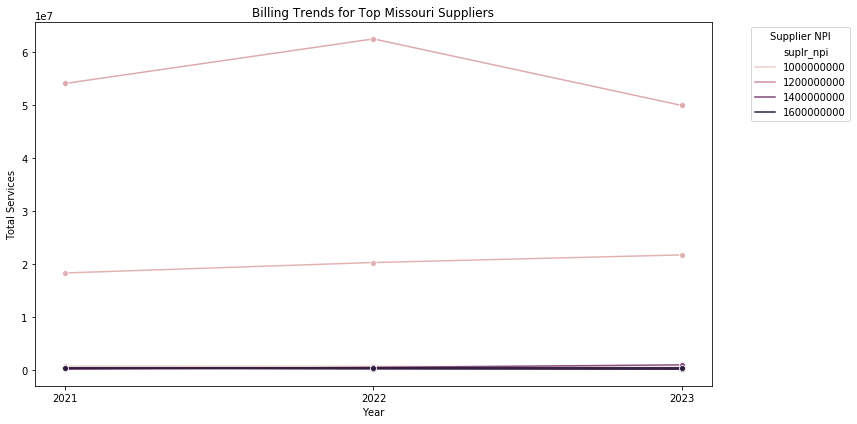

In [18]:
trend_df = trend_df[trend_df["year"].isin([2021,2022,2023])]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=trend_df,
    x="year",
    y="tot_suplr_srvcs",
    hue="suplr_npi",
    marker="o",
    ci=None
)

plt.xticks([2021,2022,2023])

plt.title("Billing Trends for Top Missouri Suppliers")
plt.xlabel("Year")
plt.ylabel("Total Services")

plt.legend(title="Supplier NPI", bbox_to_anchor=(1.05,1))

plt.tight_layout()

plt.show()

## Detecting Suspicious Billing Spikes

We identify suppliers whose billing pattern follows:

Low → High → Low

This pattern may indicate a supplier temporarily exploiting a billing opportunity.

In [20]:
pivot = (
    trend_df
    .pivot_table(
        index="suplr_npi",
        columns="year",
        values="tot_suplr_srvcs",
        aggfunc="sum"
    )
    .fillna(0)
)

pivot

year,2021,2022,2023
suplr_npi,,,
1043395833,754910,739938,531775
1114943610,18341250,20312232,21742111
1134698418,54105968,62498783,49957298
1366475022,407425,418808,413282
1376916379,165977,526736,998823
1467482281,332707,272737,250673
1528069309,393643,274509,177452
1568537009,406131,444126,429267


Suppliers are flagged if:

- 2022 billing is **higher than 2021**
- 2022 billing is **higher than 2023**

In [32]:
spike_suppliers = pivot[
    (pivot[2022] >  pivot[2021]) &
    (pivot[2022] >  pivot[2023])
]

spike_suppliers

year,2021,2022,2023,growth_21_22,drop_22_23
suplr_npi,,,,,
1134698418,54105968,62498783,49957298,0.155118,0.200668
1366475022,407425,418808,413282,0.027939,0.013195
1568537009,406131,444126,429267,0.093553,0.033457


## Dashboard Output Table

In [25]:
dashboard_table = (
    df_mo[df_mo["suplr_npi"].isin(spike_suppliers.index)]
    .groupby(["year","suplr_npi","hcpcs_cd"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

dashboard_table.head()

,year,suplr_npi,hcpcs_cd,tot_suplr_srvcs
0,2021,1134698418,J7613,14164223
1,2021,1134698418,J7677,39941745
2,2021,1366475022,B4152,407425
3,2021,1568537009,B4152,406131
4,2022,1134698418,J7613,9907535


In [30]:
pivot["growth_21_22"] = (pivot[2022] - pivot[2021]) / (pivot[2021] + 1)
pivot["drop_22_23"] = (pivot[2022] - pivot[2023]) / (pivot[2022] + 1)

spike_suppliers = pivot[
    (pivot["growth_21_22"] > 0) &
    (pivot["drop_22_23"] > 0)
]
spike_suppliers

year,2021,2022,2023,growth_21_22,drop_22_23
suplr_npi,,,,,
1134698418,54105968,62498783,49957298,0.155118,0.200668
1366475022,407425,418808,413282,0.027939,0.013195
1568537009,406131,444126,429267,0.093553,0.033457
